In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('yield_df.csv')

In [3]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [4]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [5]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [6]:
#Supervised as we have input features and output features 

In [7]:

df.shape

(28242, 7)

In [8]:
df.isnull().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


In [10]:
df.duplicated().sum()

np.int64(2310)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000


In [14]:
df.shape

(25932, 7)

In [15]:
def isStr(obj):
    try:
        float(obj) #"abs" cannot be converted to float so we go in except block
        return False
    except :
        return True

In [16]:
to_drop=df[df['average_rain_fall_mm_per_year'].apply(isStr)].index

In [17]:
df=df.drop(to_drop)

In [18]:
df.shape

(25932, 7)

In [19]:
# all values are float64 so no values are reduced
#if average_rain_fall_mm_per_year it is not in float and we want it in float 
#we will do df['average_rain_fall_mm_per_year']=
#df['average_rain_fall_mm_per_year'].astype(np.float64) as it was average rainfall

C:\Users\isha\AppData\Local\Temp\ipykernel_19656\1653247783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Area'], palette="magma")


<Axes: xlabel='count', ylabel='Area'>

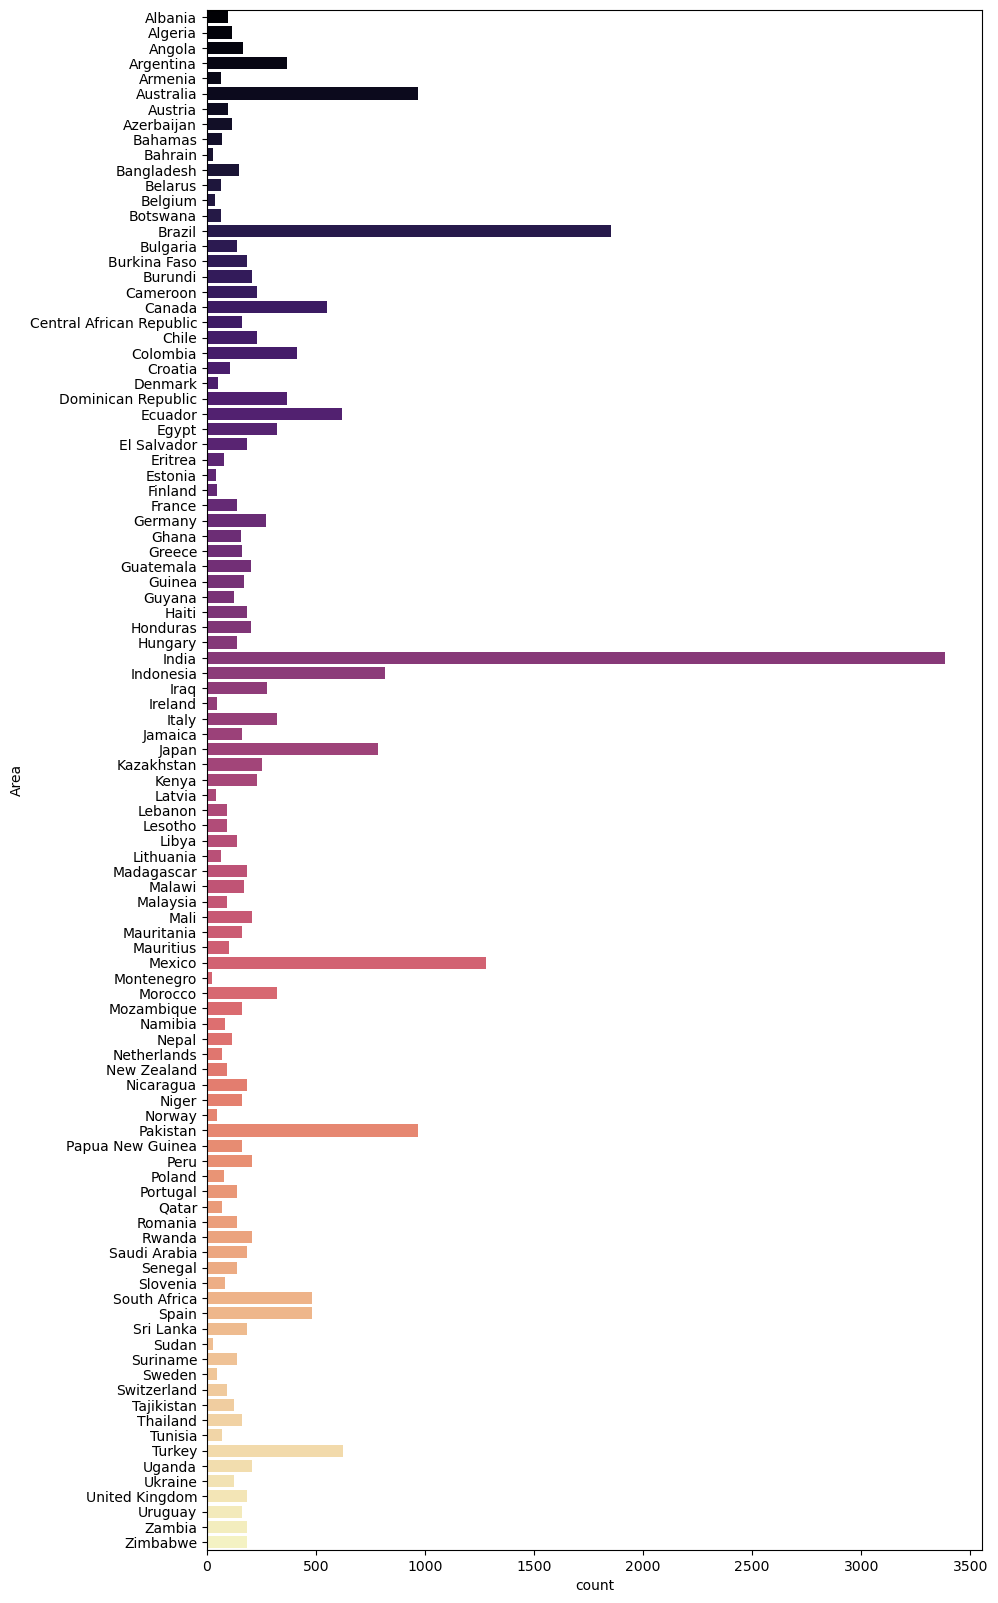

In [20]:
plt.figure(figsize=(10,20))
sns.countplot(y=df['Area'], palette="magma")

In [21]:
country=df['Area'].unique()

In [22]:
country

array(['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Belarus', 'Belgium', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cameroon', 'Canada',
       'Central African Republic', 'Chile', 'Colombia', 'Croatia',
       'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador',
       'Eritrea', 'Estonia', 'Finland', 'France', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guyana', 'Haiti', 'Honduras',
       'Hungary', 'India', 'Indonesia', 'Iraq', 'Ireland', 'Italy',
       'Jamaica', 'Japan', 'Kazakhstan', 'Kenya', 'Latvia', 'Lebanon',
       'Lesotho', 'Libya', 'Lithuania', 'Madagascar', 'Malawi',
       'Malaysia', 'Mali', 'Mauritania', 'Mauritius', 'Mexico',
       'Montenegro', 'Morocco', 'Mozambique', 'Namibia', 'Nepal',
       'Netherlands', 'New Zealand', 'Nicaragua', 'Niger', 'Norway',
       'Pakistan', 'Papua New Guinea', 'Peru', 'Pola

In [23]:
#yeild_per_country=[]
# for i in range(len(country)):
#     yeild_per_country.append(df[df['Area']==country[i]]['hg/ha_yield'].sum())
yeild_per_country=df.groupby('Area')['hg/ha_yield'].sum()


In [24]:
yeild_per_country

Area
Albania            5711536
Algeria            6711464
Angola             5722563
Argentina         32864032
Armenia            4524100
                    ...   
Ukraine            5496901
United Kingdom    44335992
Uruguay            9539820
Zambia             7254311
Zimbabwe           7408629
Name: hg/ha_yield, Length: 101, dtype: int64

C:\Users\isha\AppData\Local\Temp\ipykernel_19656\4198378390.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=country,x=yeild_per_country,palette='plasma')


<Axes: xlabel='hg/ha_yield'>

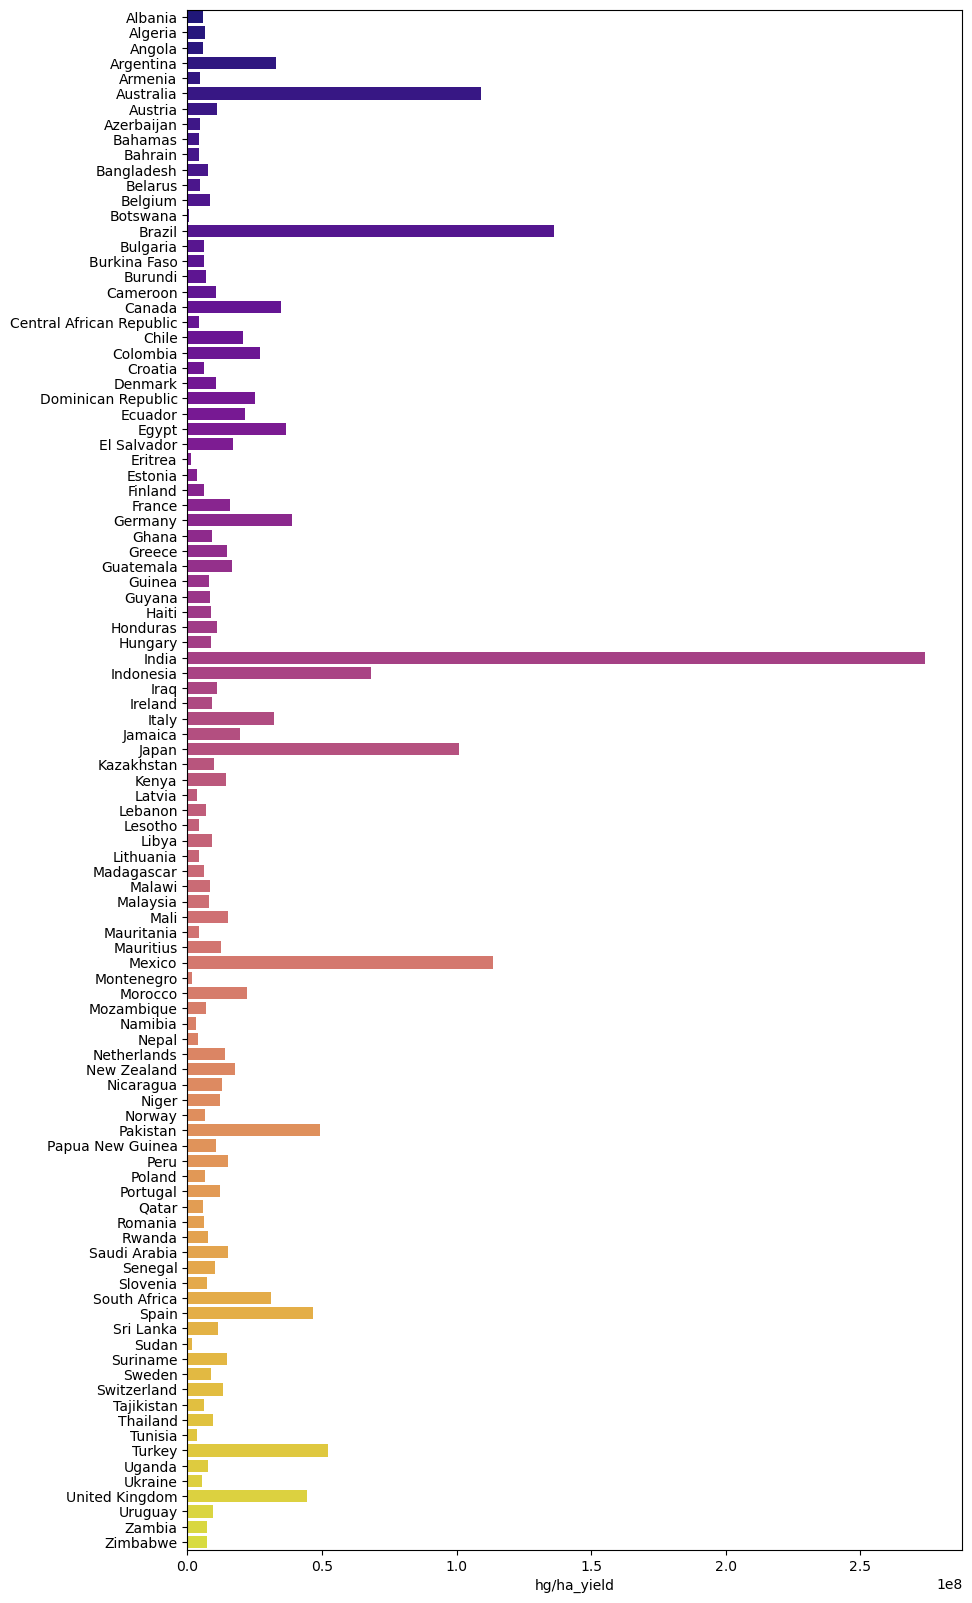

In [25]:
plt.figure(figsize=(10,20))
sns.barplot(y=country,x=yeild_per_country,palette='plasma')

In [26]:
df['Item'].value_counts()

Item
Potatoes                3956
Maize                   3824
Wheat                   3539
Rice, paddy             3091
Soybeans                2940
Sorghum                 2770
Sweet potatoes          2593
Cassava                 1889
Yams                     774
Plantains and others     556
Name: count, dtype: int64

C:\Users\isha\AppData\Local\Temp\ipykernel_19656\4278781009.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Item'],palette='magma')


<Axes: xlabel='count', ylabel='Item'>

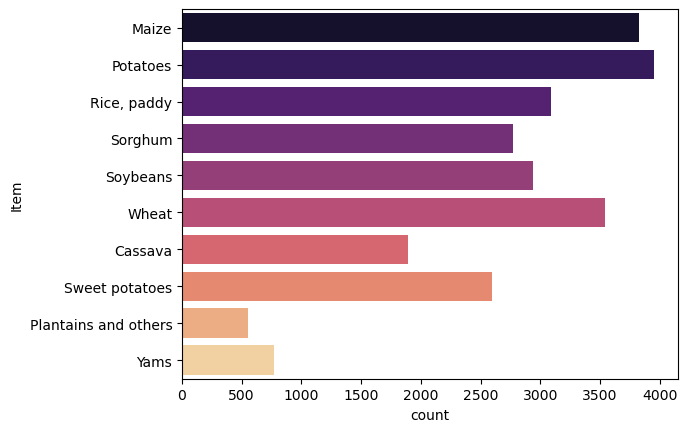

In [27]:
sns.countplot(y=df['Item'],palette='magma')

In [28]:
df['Area'].value_counts()

Area
India         3384
Brazil        1854
Mexico        1280
Australia      966
Pakistan       966
              ... 
Estonia         42
Belgium         39
Bahrain         29
Sudan           28
Montenegro      24
Name: count, Length: 101, dtype: int64

C:\Users\isha\AppData\Local\Temp\ipykernel_19656\3689749790.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Area'],palette='cividis')


<Axes: xlabel='count', ylabel='Area'>

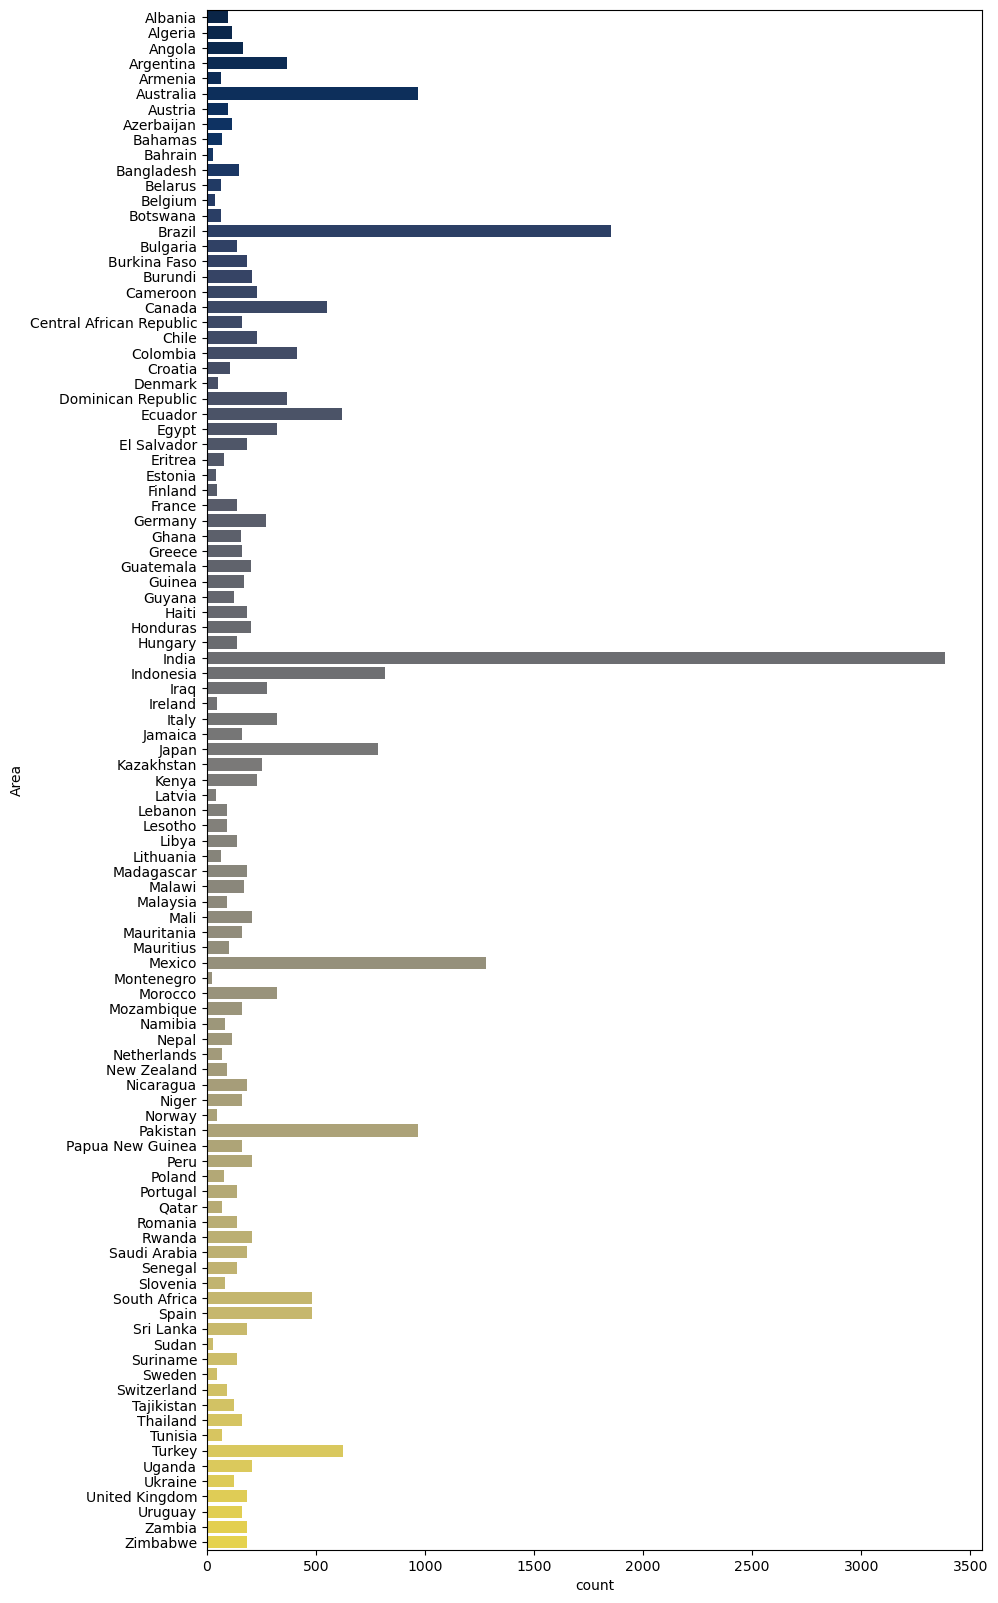

In [29]:
plt.figure(figsize=(10,20))
sns.countplot(y=df['Area'],palette='cividis')

In [30]:
crop_yield=df.groupby('Item')['hg/ha_yield'].sum()

In [31]:
crop_yield

Item
Cassava                 275132269
Maize                   142020761
Plantains and others     58958974
Potatoes                785921609
Rice, paddy             127646024
Sorghum                  52906376
Soybeans                 49957039
Sweet potatoes          310269345
Wheat                   106614786
Yams                     86769760
Name: hg/ha_yield, dtype: int64

C:\Users\isha\AppData\Local\Temp\ipykernel_19656\143482837.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df['Item'].unique(),x=crop_yield,palette='Greens')


<Axes: xlabel='hg/ha_yield'>

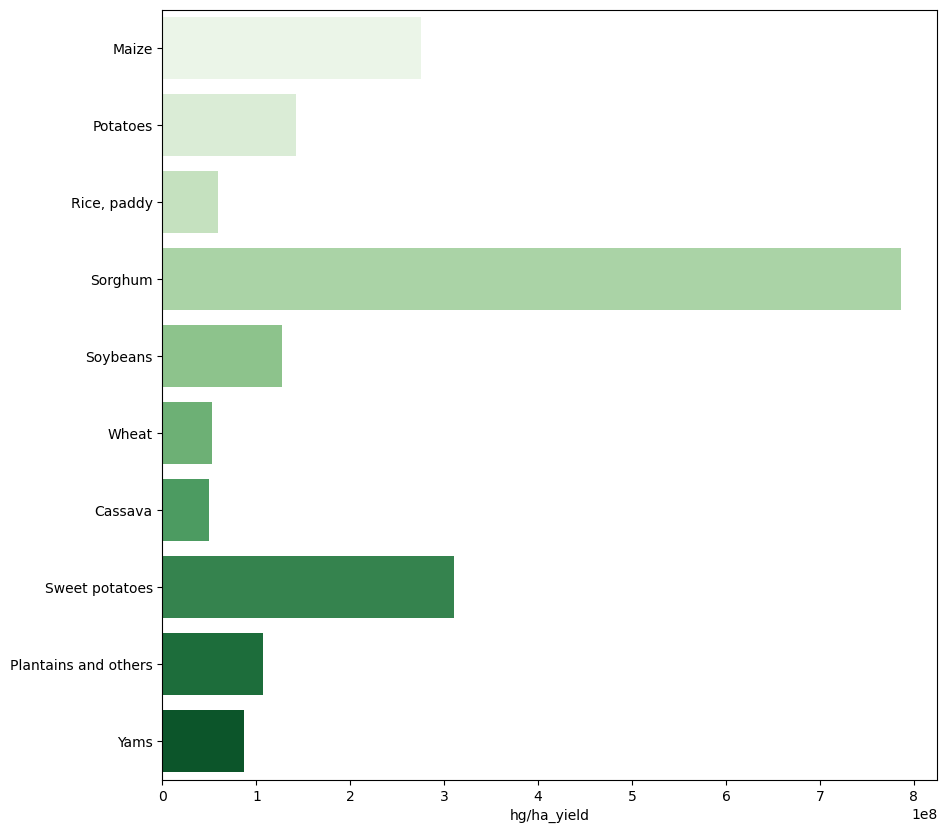

In [32]:
plt.figure(figsize=(10,10))
sns.barplot(y=df['Item'].unique(),x=crop_yield,palette='Greens')

In [33]:
#traintestsplit
col=['Year'	,'average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp','Area','Item','hg/ha_yield']

In [34]:
df=df[col]

In [35]:
df

,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item,hg/ha_yield
0,1990,1485.0,121.00,16.37,Albania,Maize,36613
1,1990,1485.0,121.00,16.37,Albania,Potatoes,66667
2,1990,1485.0,121.00,16.37,Albania,"Rice, paddy",23333
3,1990,1485.0,121.00,16.37,Albania,Sorghum,12500
4,1990,1485.0,121.00,16.37,Albania,Soybeans,7000
...,...,...,...,...,...,...,...
28237,2013,657.0,2550.07,19.76,Zimbabwe,"Rice, paddy",22581
28238,2013,657.0,2550.07,19.76,Zimbabwe,Sorghum,3066
28239,2013,657.0,2550.07,19.76,Zimbabwe,Soybeans,13142
28240,2013,657.0,2550.07,19.76,Zimbabwe,Sweet potatoes,22222


In [36]:
X=df.drop('hg/ha_yield',axis=1)
Y=df['hg/ha_yield']

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [38]:
X_train.shape

(20745, 6)

In [39]:
X_test.shape

(5187, 6)

In [40]:
Y_train.shape

(20745,)

In [41]:
from sklearn.preprocessing import  OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer 

In [42]:
ohe=OneHotEncoder(drop='first')
scaler=StandardScaler()

In [43]:
preprocessor=ColumnTransformer(
    [
        ('onehotencoder',ohe,['Area','Item']),
        ('standarisation',scaler,[0,1,2,3])
    ],
    remainder='passthrough'
)

In [44]:
preprocessor

,transformers,"[('onehotencoder', ...), ('standarisation', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [45]:
X_train_scaled=preprocessor.fit_transform(X_train)
X_test_scaled=preprocessor.transform(X_test)

In [46]:
X_train_scaled

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 122877 stored elements and shape (20745, 113)>

In [50]:
#Training model 
from sklearn.linear_model import LinearRegression,Lasso,Ridge 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,r2_score

In [51]:
models={
    'lr':LinearRegression(),
    'lass':Lasso(),
    'rg':Ridge(),
    'knn':KNeighborsRegressor(),
    'dt':DecisionTreeRegressor()
}

for name,mod in models.items():
    mod.fit(X_train_scaled,Y_train)
    y_pred=mod.predict(X_test_scaled)
    r2 = r2_score(Y_test, y_pred)
    print(f"{name} R-squared: {r2} MSE:{mean_absolute_error(Y_test,y_pred)}")

lr R-squared: 0.7486566793758742 MSE:29920.74343817363


E:\2-6-26\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.317e+10, tolerance: 1.482e+10
  model = cd_fast.sparse_enet_coordinate_descent(


lass R-squared: 0.74858422293514 MSE:29907.604370717865
rg R-squared: 0.7485422653880697 MSE:29875.37219652075
knn R-squared: 0.9824118331935128 MSE:4854.661422787739
dt R-squared: 0.9772125619763538 MSE:4103.265856950067


In [53]:
#select model decision tree
dt=DecisionTreeRegressor()
dt.fit(X_train_scaled,Y_train)
dt.predict(X_test_scaled)

array([167489.,  15838.,  72614., ...,  52692.,   9621., 132600.],
      shape=(5187,))

In [70]:
#Predictive System
def prediction(Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item):
    features = pd.DataFrame([[Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item]],
        columns=[
            'Year',
            'average_rain_fall_mm_per_year',
            'pesticides_tonnes',
            'avg_temp',
            'Area',
            'Item'
        ]
    )
    transformed_features=preprocessor.transform(features)
    predicted_value=dt.predict(transformed_features)
    return predicted_value[0]
 

In [72]:
Year=2000
average_rain_fall_mm_per_year=59.0	
pesticides_tonnes=3024.11		
avg_temp=26.55
Area='Saudi Arabia'
Item='Sorghum'

result=prediction(Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item)
result

np.float64(13384.0)

In [59]:
X_train

,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item
24234,2000,59.0,3024.11,26.55,Saudi Arabia,Sorghum
9468,2012,652.0,8002.20,18.82,Greece,Sweet potatoes
6793,2006,3240.0,98328.63,27.51,Colombia,Maize
28212,2010,657.0,3305.17,21.17,Zimbabwe,Potatoes
7358,2007,1410.0,5689.80,27.08,Dominican Republic,Sweet potatoes
...,...,...,...,...,...,...
23678,2004,854.0,16942.00,16.31,Portugal,Sweet potatoes
5960,2006,537.0,36572.75,7.85,Canada,Wheat
860,1991,534.0,17866.00,18.73,Australia,Potatoes
17223,1998,250.0,6416.14,6.94,Kazakhstan,Potatoes


In [74]:
import pickle
pickle.dump(dt,open('dt.pkl','wb'))
pickle.dump(preprocessor,open('preprocessor.pkl','wb'))

In [75]:
import sklearn
print(sklearn.__version__)

1.7.2
